In [74]:
import pandas as pd

In [75]:
df = pd.read_csv("D:\\DataAnalysis\\Py_projects\\restaurant_analysis\\data\\raw\\raw_rest_data.csv")

In [77]:
df.describe()

,Order_ID,Item_Name,Quantity,Total_Price,Customer_Type,Feedback,Discount_Applied,Delivery_Location
count,579,579,568,558,556,485,178,6
unique,116,67,33,14,14,32,10,2
top,SW-216| 2025-04-14,Chicken Biryani | 2,New,Returning,Good,0,Indirapuram,Greater Noida
freq,464,31,46,235,175,78,48,3


In [4]:
df.columns

Index(['Order_ID', 'Item_Name', 'Quantity', 'Total_Price', 'Customer_Type',
       'Feedback', 'Discount_Applied', 'Delivery_Location'],
      dtype='object')

In [5]:
combined = df.fillna('').astype(str).agg('|'.join, axis = 1) 
combined.head()

0    SW-101 | 2025-04-01 | veg biryani | 2 | 400 | ...
1    SW-102 |2025-04-02|Chicken Tikka Masala|1|350|...
2    sw-103|2025-04-02|  Butter Naan |4|200| Return...
3    SW-104 | 2025-04-05 | Paneer Butter Masala | 1...
4    SW-105|2025-04-06|Garlic Bread| 2 |180|Returni...
dtype: object

In [6]:
combined = (combined.str.replace(r'\|+', '|', regex= True).str.strip('|'))

In [7]:
final_df = combined.str.split('|', expand = True)


In [12]:
final_df.columns = ['Order_ID',
    'Date',
    'Item_Name',
    'Quantity',
    'Total_Price',
    'Customer_Type',
    'Feedback',
    'Discount_Applied',
    'Delivery_Location'
    ]
                

In [13]:
final_df.head(10)

,Order_ID,Date,Item_Name,Quantity,Total_Price,Customer_Type,Feedback,Discount_Applied,Delivery_Location
0,SW-101,2025-04-01,veg biryani,2,400,returning,Good,0,Connaught Place
1,SW-102,2025-04-02,Chicken Tikka Masala,1,350,New,Excellent,50,Saket
2,sw-103,2025-04-02,Butter Naan,4,200,Returning,Average,0,Karol Bagh
3,SW-104,2025-04-05,Paneer Butter Masala,1,250,new,Good,20,Hauz Khas
4,SW-105,2025-04-06,Garlic Bread,2,180,Returning,Good,0,Lajpat Nagar
5,sw-106,2025-04-06,veg biryani,1,200,New,Average,10,Connaught Place
6,SW-107,2025-04-08,Chicken Biryani,2,500,RETURNING,EXCELLENT,0,Rajouri Garden
7,SW-108,2025-04-08,Dal Makhani,1,180,returning,Good,30,Saket
8,sw-109,2025-04-09,Mixed Veg Curry,3,450,new,average,0,Karol Bagh
9,SW-110,2025-04-10,Fish Curry,1,300,RETURNING,EXCELLENT,50,Lajpat Nagar


In [14]:
print(type(final_df))

<class 'pandas.core.frame.DataFrame'>


In [15]:
# Trim spaces from column
# Replace multiple exact value
final_df['Customer_Type'] = final_df['Customer_Type'].str.strip()
mapping = {'RETURNING':'Returning', 'returning':'Returning', 'new':'New'}
final_df['Customer_Type'] = final_df['Customer_Type'].replace(mapping)

In [ ]:
final_df['Feedback'] = final_df['Feedback'].str.strip()
mapping = {'EXCELLENT':'Excellent'}
final_df['Feedback'] = final_df['Feedback'].replace(mapping)

In [16]:
# Trim spaces from columns
final_df = final_df.apply(lambda col : col.str.strip())

In [19]:
final_df.head(10)


,Order_ID,Date,Item_Name,Quantity,Total_Price,Customer_Type,Feedback,Discount_Applied,Delivery_Location
0,SW-101,2025-04-01,veg biryani,2,400,Returning,Good,0,Connaught Place
1,SW-102,2025-04-02,Chicken Tikka Masala,1,350,New,Excellent,50,Saket
2,sw-103,2025-04-02,Butter Naan,4,200,Returning,Average,0,Karol Bagh
3,SW-104,2025-04-05,Paneer Butter Masala,1,250,New,Good,20,Hauz Khas
4,SW-105,2025-04-06,Garlic Bread,2,180,Returning,Good,0,Lajpat Nagar
5,sw-106,2025-04-06,veg biryani,1,200,New,Average,10,Connaught Place
6,SW-107,2025-04-08,Chicken Biryani,2,500,Returning,Excellent,0,Rajouri Garden
7,SW-108,2025-04-08,Dal Makhani,1,180,Returning,Good,30,Saket
8,sw-109,2025-04-09,Mixed Veg Curry,3,450,New,average,0,Karol Bagh
9,SW-110,2025-04-10,Fish Curry,1,300,Returning,Excellent,50,Lajpat Nagar


In [20]:
final_df.shape

(579, 9)

In [21]:
print(final_df.dtypes)

Order_ID             object
Date                 object
Item_Name            object
Quantity             object
Total_Price          object
Customer_Type        object
Feedback             object
Discount_Applied     object
Delivery_Location    object
dtype: object


In [22]:
print(type(final_df))

<class 'pandas.core.frame.DataFrame'>


In [17]:
# Change data types
final_df['Date'] = pd.to_datetime(final_df['Date'], dayfirst = True, format = 'mixed')
final_df['Quantity'] = pd.to_numeric(final_df['Quantity'], errors = 'coerce').astype('Int64')
# If Total_Price contains decimal, .astype(Int64) should not be used
final_df['Total_Price'] = pd.to_numeric(final_df['Total_Price'], errors = 'coerce')
final_df['Discount_Applied'] = pd.to_numeric(final_df['Discount_Applied'], errors = 'coerce').astype('Int64')

In [87]:
print(type(final_df))

<class 'pandas.core.frame.DataFrame'>


In [18]:
print(final_df.dtypes)

Order_ID                     object
Date                 datetime64[ns]
Item_Name                    object
Quantity                      Int64
Total_Price                   int64
Customer_Type                object
Feedback                     object
Discount_Applied              Int64
Delivery_Location            object
dtype: object


In [24]:
print(final_df.columns.tolist())

['Order_ID', 'Date', 'Item_Name', 'Quantity', 'Total_Price', 'Customer_Type', 'Feedback', 'Discount_Applied', 'Delivery_Location']


# If you want to delete the last column regardless of its name
# final_df = final_df.iloc[:, :-1]
# final_df.drop(columns=['Total_price', 'Qty']) OR final_df.drop('Total_price', axis = 1)

In [19]:
# Convert all text columns at once
text_cols= ['Order_ID',
            'Item_Name',
            'Customer_Type',
            'Feedback',
            'Delivery_Location'            
    
]
final_df[text_cols] = final_df[text_cols].astype('string')

In [20]:
print(final_df.dtypes)

Order_ID             string[python]
Date                 datetime64[ns]
Item_Name            string[python]
Quantity                      Int64
Total_Price                   int64
Customer_Type        string[python]
Feedback             string[python]
Discount_Applied              Int64
Delivery_Location    string[python]
dtype: object


In [27]:
print(final_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 579 entries, 0 to 578
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order_ID           579 non-null    string        
 1   Date               579 non-null    datetime64[ns]
 2   Item_Name          579 non-null    string        
 3   Quantity           579 non-null    Int64         
 4   Total_Price        579 non-null    int64         
 5   Customer_Type      579 non-null    string        
 6   Feedback           579 non-null    string        
 7   Discount_Applied   579 non-null    Int64         
 8   Delivery_Location  571 non-null    string        
dtypes: Int64(2), datetime64[ns](1), int64(1), string(5)
memory usage: 42.0 KB
None


In [42]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 579 entries, 0 to 578
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order_ID           579 non-null    string        
 1   Date               579 non-null    datetime64[ns]
 2   Item_Name          579 non-null    string        
 3   Quantity           579 non-null    Int64         
 4   Total_Price        579 non-null    int64         
 5   Customer_Type      579 non-null    string        
 6   Feedback           579 non-null    string        
 7   Discount_Applied   579 non-null    Int64         
 8   Delivery_Location  571 non-null    string        
dtypes: Int64(2), datetime64[ns](1), int64(1), string(5)
memory usage: 42.0 KB


BUSINESS ANALYSIS - KPIs

In [30]:
# Total Revenue
rev_total = final_df['Total_Price'].sum()
print(f" Total Revenue :₹{rev_total:,.2f}")

 Total Revenue :₹158,410.00


In [31]:
# Total Order(distinct Order)
total_order = final_df['Order_ID'].nunique()
print(f" Total Distinct Orders :{total_order:,.0f}") 

 Total Distinct Orders :116


In [32]:
# Total Order(including each row)
total_order = final_df['Order_ID'].count()
print(f" Total Orders :{total_order:,.0f}") 

 Total Orders :579


In [119]:
#Average Order Value
avg_order = final_df['Total_Price'].mean()
print(f"Average Order value = ₹{avg_order:,.0f}")

Average Order value = ₹274


In [33]:
# Maximum Order Value
max_order =final_df['Total_Price'].max()
print(f"Max Order Value: ₹{max_order:,.2f}")

Max Order Value: ₹500.00


Phase II (Customer Analysis)

In [34]:
# New Customer vs Returning
final_df["Customer_Type"].value_counts()

Customer_Type
New          290
Returning    289
Name: count, dtype: Int64

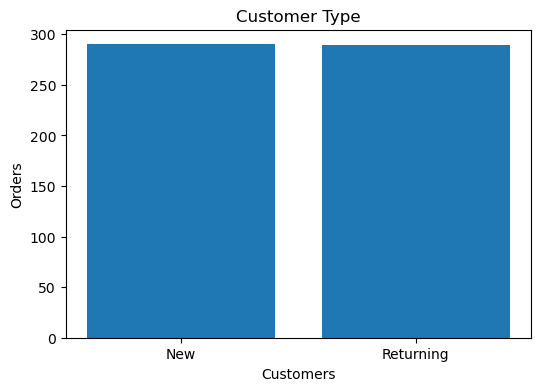

In [35]:
import matplotlib.pyplot as plt
customers = final_df["Customer_Type"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(customers.index, customers.values)
plt.title("Customer Type")
plt.xlabel("Customers")
plt.ylabel("Orders")

plt.show()

In [40]:
# Customer Feedback
final_df["Feedback"].unique()


<StringArray>
['Good', 'Excellent', 'Average']
Length: 3, dtype: string

In [37]:
final_df["Feedback"] = final_df["Feedback"].replace({
    "average" : "Average",
    
})

In [41]:
final_df['Feedback'].unique()

<StringArray>
['Good', 'Excellent', 'Average']
Length: 3, dtype: string

In [39]:
final_df.to_csv("D:\\DataAnalysis\\Py_projects\\restaurant_analysis\\data\\cleaned\\clnd_rest_data.csv", index = False)
final_df.to_excel("D:\\DataAnalysis\\Py_projects\\restaurant_analysis\\data\\cleaned\\clnd_rest_data.xlsx", index=False)

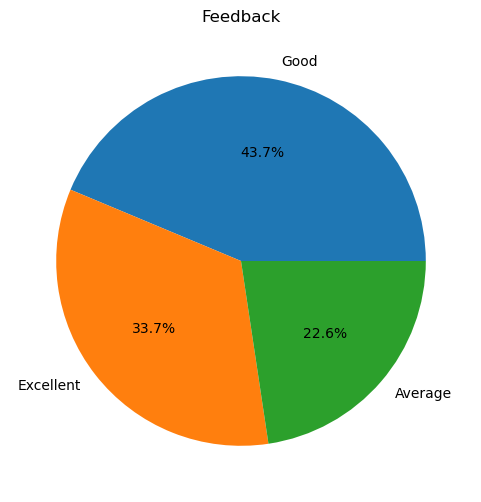

In [42]:
feedback = final_df["Feedback"].value_counts()

plt.figure(figsize =(6,6))
plt.pie(feedback, labels = feedback.index, autopct = '%1.1f%%')
plt.title("Feedback")
plt.show()


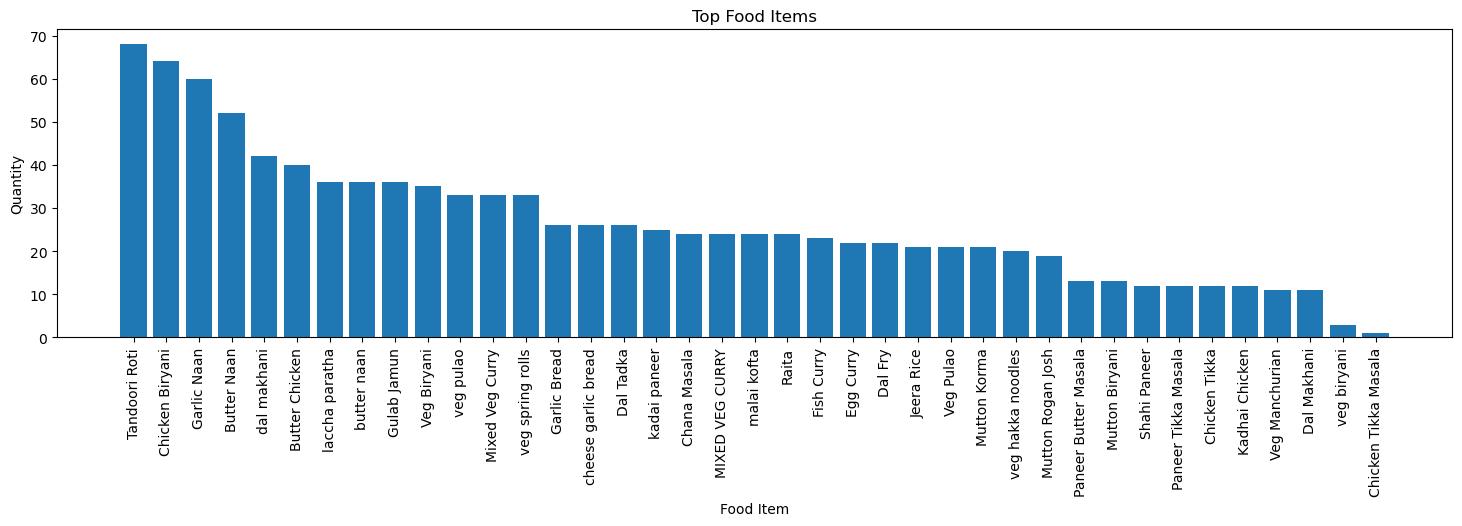

In [43]:
# Product Analysis
# Best Selling Items
top_food = (final_df.groupby('Item_Name')['Quantity'].sum().sort_values(ascending=False))

plt.figure(figsize=(18,4))
plt.bar(top_food.index, top_food.values)
plt.title("Top Food Items")
plt.xlabel("Food Item")
plt.ylabel("Quantity")
plt.xticks(rotation = 90)

plt.show()

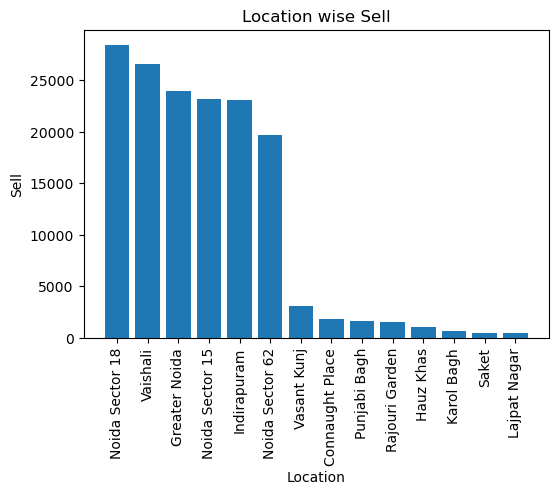

In [44]:
# Location Analysis
location = final_df.groupby('Delivery_Location')['Total_Price'].sum().sort_values(ascending=False)

plt.figure(figsize=(6,4))
plt.bar(location.index, location.values)
plt.title("Location wise Sell")
plt.xlabel("Location")
plt.ylabel("Sell")
plt.xticks(rotation=90)
plt.show()


In [47]:
loc = final_df['Delivery_Location'].value_counts()


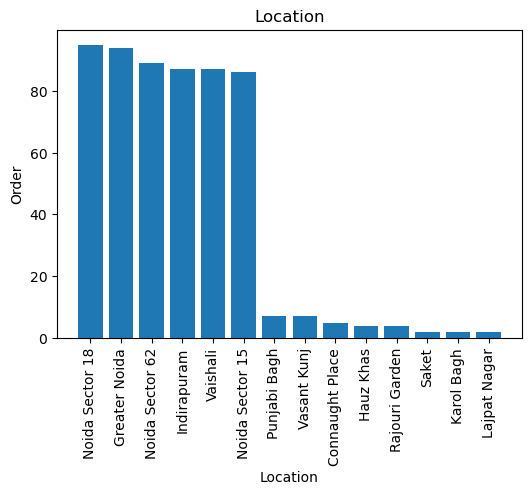

In [48]:
plt.figure(figsize=(6,4))
plt.bar(loca.index, loc.values)
plt.title("Location")
plt.xlabel("Location")
plt.ylabel("Order")
plt.xticks(rotation=90)
plt.show()

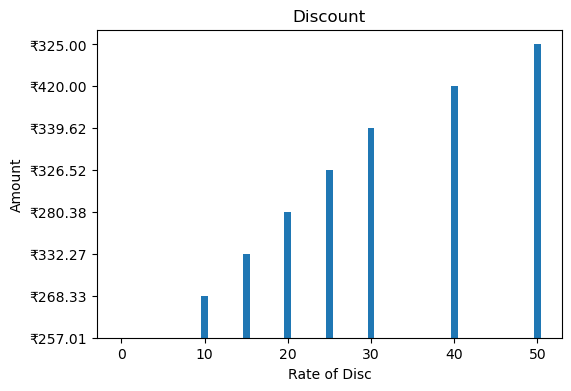

In [49]:
# Discount vs Revenue

disc = final_df.groupby("Discount_Applied")["Total_Price"].mean().map('₹{:,.2f}'.format)   # Use .map() to apply formatting element-wise
 
plt.figure(figsize=(6,4))
plt.bar(disc.index, disc.values)
plt.title("Discount")
plt.xlabel("Rate of Disc")
plt.ylabel("Amount")

plt.show()

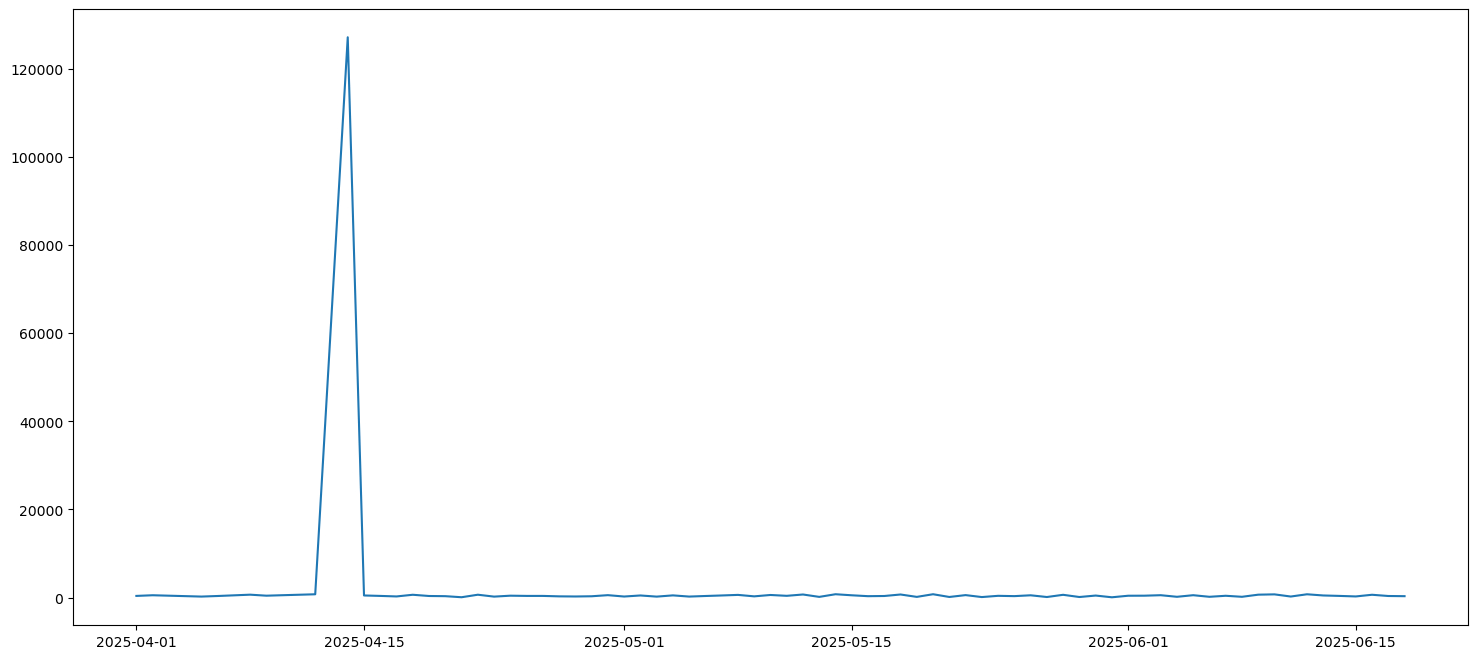

In [50]:
# Daily Revenue
daily_rev = final_df.groupby("Date")["Total_Price"].sum()

plt.figure(figsize=(18,8), frameon=False, dpi=100)
plt.plot(daily_rev.index,daily_rev.values)

plt.show()


PHASE II, Intermidiate Business Analysis

In [51]:
# Multi-level Group By : Which Item best selling in each locatiion?

table1 = final_df.groupby(['Delivery_Location', 'Item_Name'])['Total_Price'].sum()
print(table1)

Delivery_Location  Item_Name        
Connaught Place    veg biryani           600
                   veg pulao            1260
Greater Noida      Butter Chicken       2500
                   Chana Masala         1200
                   Egg Curry            1300
                                        ... 
Vaishali           kadai paneer         1400
                   laccha paratha        840
                   malai kofta          2240
                   veg pulao            1680
Vasant Kunj        Mutton Rogan Josh    3150
Name: Total_Price, Length: 108, dtype: int64


In [52]:
# Each Item sold data
item_data = final_df.groupby('Item_Name').agg(
     Quantity= ('Quantity', 'sum'),
     Revenue= ('Total_Price', 'sum'),
     Orders= ('Order_ID', 'count'),
     Average =('Total_Price','mean')
    
)
print(item_data)


                      Quantity  Revenue  Orders     Average
Item_Name                                                  
Butter Chicken              40    10000      20  500.000000
Butter Naan                 52     2600      13  200.000000
Chana Masala                24     2880      12  240.000000
Chicken Biryani             64    16000      32  500.000000
Chicken Tikka               12     3000      12  250.000000
Chicken Tikka Masala         1      350       1  350.000000
Dal Fry                     22     2640      11  240.000000
Dal Makhani                 11     1980      11  180.000000
Dal Tadka                   26     3480      19  183.157895
Egg Curry                   22     2860      11  260.000000
Fish Curry                  23     7500      23  326.086957
Garlic Bread                26     2340      13  180.000000
Garlic Naan                 60     3600      20  180.000000
Gulab Jamun                 36     2160      12  180.000000
Jeera Rice                  21     2940 

In [46]:
# Pivot Table
pivot= pd.pivot_table(
       final_df,
       index = 'Delivery_Location',
       columns = 'Item_Name',
       values = 'Total_Price',
       aggfunc = 'sum'
   )
print(pivot)

Item_Name          Butter Chicken  Butter Naan  Chana Masala  Chicken Biryani  \
Delivery_Location                                                               
Connaught Place               NaN          NaN           NaN              NaN   
Greater Noida              2500.0          NaN        1200.0              NaN   
Hauz Khas                     NaN          NaN           NaN              NaN   
Indirapuram                   NaN          NaN           NaN           5500.0   
Karol Bagh                    NaN        200.0           NaN              NaN   
Lajpat Nagar                  NaN          NaN           NaN              NaN   
Noida Sector 15               NaN       1000.0        1680.0           2500.0   
Noida Sector 18            5500.0       1400.0           NaN              NaN   
Noida Sector 62               NaN          NaN           NaN           2000.0   
Punjabi Bagh                  NaN          NaN           NaN              NaN   
Rajouri Garden              

In [53]:
# Pivot Table
pivot= pd.pivot_table(
       final_df,
       index = 'Item_Name',
       columns = 'Customer_Type',
       values = 'Total_Price',
       aggfunc = 'sum'
   )
print(pivot)

Customer_Type            New  Returning
Item_Name                              
Butter Chicken           NaN    10000.0
Butter Naan           2400.0      200.0
Chana Masala             NaN     2880.0
Chicken Biryani       5500.0    10500.0
Chicken Tikka            NaN     3000.0
Chicken Tikka Masala   350.0        NaN
Dal Fry               2640.0        NaN
Dal Makhani              NaN     1980.0
Dal Tadka             1800.0     1680.0
Egg Curry                NaN     2860.0
Fish Curry            4200.0     3300.0
Garlic Bread          2160.0      180.0
Garlic Naan              NaN     3600.0
Gulab Jamun           2160.0        NaN
Jeera Rice               NaN     2940.0
Kadhai Chicken           NaN     3840.0
MIXED VEG CURRY          NaN     3600.0
Mixed Veg Curry       4950.0        NaN
Mutton Biryani           NaN     4550.0
Mutton Korma             NaN     7980.0
Mutton Rogan Josh     8550.0        NaN
Paneer Butter Masala   250.0     3000.0
Paneer Tikka Masala   3600.0        NaN


In [48]:
# Which customer type gives which feedback

fedback = pd.crosstab(
    final_df['Customer_Type'],
    final_df['Feedback']
)
print(fedback)

Feedback       Average  Excellent  Good  average
Customer_Type                                   
New                102         72   115        1
Returning           28        123   138        0


In [49]:
# Top 10 Food Items
top10 = final_df.groupby('Item_Name')['Total_Price'].sum().nlargest(10)
print(top10)

Item_Name
Chicken Biryani      16000
Butter Chicken       10000
Mutton Rogan Josh     8550
Mutton Korma          7980
Fish Curry            7500
Veg Biryani           7000
kadai paneer          7000
Mixed Veg Curry       4950
veg pulao             4620
Mutton Biryani        4550
Name: Total_Price, dtype: int64


In [54]:
# Window Functions
# Running Revenue
daily = (
    final_df.groupby('Date')['Total_Price']
    .sum().sort_index()
)
daily.cumsum()

Date
2025-04-01       400
2025-04-02       950
2025-04-05      1200
2025-04-06      1580
2025-04-08      2260
               ...  
2025-06-14    156750
2025-06-15    157030
2025-06-16    157690
2025-06-17    158070
2025-06-18    158410
Name: Total_Price, Length: 74, dtype: int64

In [55]:
# Moving Average
daily.rolling(5).mean()

Date
2025-04-01      NaN
2025-04-02      NaN
2025-04-05      NaN
2025-04-06      NaN
2025-04-08    452.0
              ...  
2025-06-14    536.0
2025-06-15    442.0
2025-06-16    522.0
2025-06-17    444.0
2025-06-18    412.0
Name: Total_Price, Length: 74, dtype: float64

In [56]:
# Extract Month & Year 
final_df['Month'] = final_df['Date'].dt.month_name()
final_df['Year'] = final_df['Date'].dt.year
final_df['Qtr'] = final_df['Date'].dt.quarter
final_df['Weekday'] =final_df['Date'].dt.day_name()

In [57]:
# Additional 4 columns
final_df.head(5)

,Order_ID,Date,Item_Name,Quantity,Total_Price,Customer_Type,Feedback,Discount_Applied,Delivery_Location,Month,Year,Qtr,Weekday
0,SW-101,2025-04-01,veg biryani,2,400,Returning,Good,0,Connaught Place,April,2025,2,Tuesday
1,SW-102,2025-04-02,Chicken Tikka Masala,1,350,New,Excellent,50,Saket,April,2025,2,Wednesday
2,sw-103,2025-04-02,Butter Naan,4,200,Returning,Average,0,Karol Bagh,April,2025,2,Wednesday
3,SW-104,2025-04-05,Paneer Butter Masala,1,250,New,Good,20,Hauz Khas,April,2025,2,Saturday
4,SW-105,2025-04-06,Garlic Bread,2,180,Returning,Good,0,Lajpat Nagar,April,2025,2,Sunday


In [58]:
# Customer Retention
retention = final_df.groupby([
    'Customer_Type', 'Month'
])['Order_ID'].count()

print(retention)

Customer_Type  Month
New            April    252
               June      14
               May       24
Returning      April    251
               June      14
               May       24
Name: Order_ID, dtype: int64


In [59]:
#Corelation
final_df.corr(numeric_only = True)

,Quantity,Total_Price,Discount_Applied,Year,Qtr
Quantity,1.000000,-0.147303,-0.205528,NaN,NaN
Total_Price,-0.147303,1.000000,0.220200,NaN,NaN
Discount_Applied,-0.205528,0.220200,1.000000,NaN,NaN
Year,NaN,NaN,NaN,NaN,NaN
Qtr,NaN,NaN,NaN,NaN,NaN


In [60]:
# Find Outliers : Used before ML
Q1 = final_df['Total_Price'].quantile(.25)
Q3 = final_df['Total_Price'].quantile(.75)

IQR = Q3-Q1
print(IQR)


170.0


In [228]:
# Feature Engineering : Create New Column
final_df['Unit_Price'] = (final_df['Total_Price'] / final_df['Quantity'])


In [61]:
# Lambda function
final_df['Imp_Cust'] = final_df['Total_Price'].apply(
    lambda x: 'Yes' if x >= 400 else 'No'
)

In [62]:
final_df.head(10)

,Order_ID,Date,Item_Name,Quantity,Total_Price,Customer_Type,Feedback,Discount_Applied,Delivery_Location,Month,Year,Qtr,Weekday,Imp_Cust
0,SW-101,2025-04-01,veg biryani,2,400,Returning,Good,0,Connaught Place,April,2025,2,Tuesday,Yes
1,SW-102,2025-04-02,Chicken Tikka Masala,1,350,New,Excellent,50,Saket,April,2025,2,Wednesday,No
2,sw-103,2025-04-02,Butter Naan,4,200,Returning,Average,0,Karol Bagh,April,2025,2,Wednesday,No
3,SW-104,2025-04-05,Paneer Butter Masala,1,250,New,Good,20,Hauz Khas,April,2025,2,Saturday,No
4,SW-105,2025-04-06,Garlic Bread,2,180,Returning,Good,0,Lajpat Nagar,April,2025,2,Sunday,No
5,sw-106,2025-04-06,veg biryani,1,200,New,Average,10,Connaught Place,April,2025,2,Sunday,No
6,SW-107,2025-04-08,Chicken Biryani,2,500,Returning,Excellent,0,Rajouri Garden,April,2025,2,Tuesday,Yes
7,SW-108,2025-04-08,Dal Makhani,1,180,Returning,Good,30,Saket,April,2025,2,Tuesday,No
8,sw-109,2025-04-09,Mixed Veg Curry,3,450,New,Average,0,Karol Bagh,April,2025,2,Wednesday,Yes
9,SW-110,2025-04-10,Fish Curry,1,300,Returning,Excellent,50,Lajpat Nagar,April,2025,2,Thursday,No


# Merge two tables,say orders and customers,
orders.merge(customers, 
             on = 'Customer_ID')

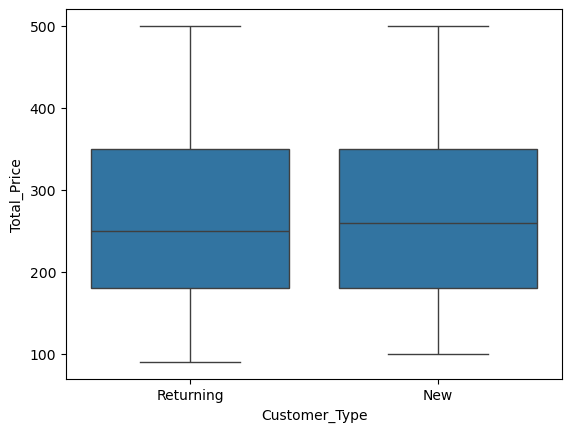

In [63]:
import seaborn as sns

sns.boxplot(data = final_df, x = 'Customer_Type', y = 'Total_Price')
plt.show()

In [30]:
items_rev = final_df.groupby("Item_Name")["Total_Price"].sum().sort_values(ascending=False)
print(items_rev)

Item_Name
Chicken Biryani         16000
Butter Chicken          10000
Mutton Rogan Josh        8550
Mutton Korma             7980
Fish Curry               7500
Veg Biryani              7000
kadai paneer             7000
Mixed Veg Curry          4950
veg pulao                4620
Mutton Biryani           4550
veg hakka noodles        4400
dal makhani              4200
Kadhai Chicken           3840
Shahi Paneer             3840
malai kofta              3840
Paneer Tikka Masala      3600
MIXED VEG CURRY          3600
Garlic Naan              3600
Dal Tadka                3480
cheese garlic bread      3380
Veg Pulao                3360
veg spring rolls         3300
Paneer Butter Masala     3250
Chicken Tikka            3000
Jeera Rice               2940
Chana Masala             2880
Egg Curry                2860
Dal Fry                  2640
Butter Naan              2600
Garlic Bread             2340
Veg Manchurian           2200
Gulab Jamun              2160
Dal Makhani              1980


In [33]:
top7_items_rev = items_rev.head(7)

print(top7_items_rev)

Item_Name
Chicken Biryani      16000
Butter Chicken       10000
Mutton Rogan Josh     8550
Mutton Korma          7980
Fish Curry            7500
Veg Biryani           7000
kadai paneer          7000
Name: Total_Price, dtype: int64


In [34]:
total_rev = final_df['Total_Price'].sum()
print(total_rev)

158410


In [36]:
top7_rev = top7_items_rev.sum()
print(top7_rev)

64030


In [46]:
top7_contribute = (top7_rev / total_rev *100)
print(f'Top7 Contribution: {top7_contribute:.1f}%')

Top7 Contribution: 40.4%


In [50]:
items_count = final_df['Item_Name'].nunique()
print(items_count)

39


In [57]:
items_rev = final_df.groupby('Item_Name')['Total_Price'].sum().sort_values(ascending=False)


pareto = pd.DataFrame({'Total_Price':items_rev}).reset_index()

pareto['Revenue %'] = (pareto['Total_Price']/pareto['Total_Price'].sum()*100).round(2)
pareto['Cumulative %'] = pareto['Revenue %'].cumsum().round(2)
print(pareto)


               Item_Name  Total_Price  Revenue %  Cumulative %
0        Chicken Biryani        16000      10.10         10.10
1         Butter Chicken        10000       6.31         16.41
2      Mutton Rogan Josh         8550       5.40         21.81
3           Mutton Korma         7980       5.04         26.85
4             Fish Curry         7500       4.73         31.58
5            Veg Biryani         7000       4.42         36.00
6           kadai paneer         7000       4.42         40.42
7        Mixed Veg Curry         4950       3.12         43.54
8              veg pulao         4620       2.92         46.46
9         Mutton Biryani         4550       2.87         49.33
10     veg hakka noodles         4400       2.78         52.11
11           dal makhani         4200       2.65         54.76
12        Kadhai Chicken         3840       2.42         57.18
13          Shahi Paneer         3840       2.42         59.60
14           malai kofta         3840       2.42       

In [63]:
weekend = final_df[final_df['Date'].dt.weekday >= 5]

weekend.groupby('Item_Name')['Total_Price'].sum().sort_values(ascending = False)
weekend_rev = weekend['Total_Price'].sum()
print(weekend_rev)
weekend_contribute = (weekend_rev / total_rev * 100).round(2)
print(weekend_contribute)

8320
5.25


In [64]:
final_df['Date'].min()

Timestamp('2025-04-01 00:00:00')

In [65]:
final_df['Date'].max()

Timestamp('2025-06-18 00:00:00')

In [69]:
final_df['Date'].dt.day_name().value_counts()

Date
Monday       480
Tuesday       18
Wednesday     18
Saturday      18
Thursday      17
Sunday        15
Friday        13
Name: count, dtype: int64

In [71]:
final_df.groupby('Date').size().sort_values(ascending=False).head(20)

Date
2025-04-14    466
2025-06-18      2
2025-05-14      2
2025-05-02      2
2025-05-04      2
2025-06-05      2
2025-05-06      2
2025-05-08      2
2025-06-03      2
2025-05-10      2
2025-05-12      2
2025-04-02      2
2025-05-15      2
2025-04-30      2
2025-05-16      2
2025-05-17      2
2025-05-18      2
2025-06-01      2
2025-05-20      2
2025-05-22      2
dtype: int64

In [73]:
final_df.groupby('Date')['Order_ID'].count().sort_values(ascending=False)

Date
2025-04-14    466
2025-06-18      2
2025-05-14      2
2025-05-02      2
2025-05-04      2
             ... 
2025-05-11      1
2025-05-19      1
2025-05-21      1
2025-05-23      1
2025-05-13      1
Name: Order_ID, Length: 74, dtype: int64